## ¿Qué estamos viendo?

Es un archivo con **1,000 filas** y **15 columnas**. La estructura se divide principalmente en dos partes:

- **Identificadores y Contenido:** Las columnas `CommentId`, `VideoId` y `Text`. Esta última es la más importante, pues contiene el mensaje real que escribió el usuario.

- **Etiquetas (Labels):** Tienes **12 columnas booleanas** (`True`/`False`) que clasifican ese texto. No solo dice si es *"tóxico"*, sino que lo desglosa en categorías específicas como racismo, sexismo, homofobia, etc.

## Lo Bueno y lo Malo

| Aspecto | ✅ Lo Bueno (Ventajas) | ⚠️ Lo Malo (Desafíos/Riesgos) |
|---|---|---|
| **Calidad de Datos** | **Cero valores nulos:** Según `df.info()`, todas las columnas tienen 1,000 datos no nulos. Está muy limpio. | **Sesgo Lingüístico:** Solo está en inglés, lo que limita su uso para otros idiomas sin traducción previa. |
| **Estructura** | **Granulado:** No es solo "tóxico o no", sino que distingue entre amenazas, obscenidad, etc. | **Subjetividad:** Lo que para un etiquetador es "provocativo", para otro podría no serlo. La toxicidad es cultural. |
| **Técnico** | **Ligero:** El dataset pesa solo 35.3 KB, lo que lo hace perfecto para prototipos rápidos. | **Tamaño:** 1,000 ejemplos es poco para un modelo de IA profesional (Deep Learning suele requerir decenas de miles). |

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Cargar el dataset
df = pd.read_csv('../../data/raw/youtoxic_english_1000.csv')
df.head()   
df.info()   
df.describe()   




<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   CommentId        1000 non-null   object
 1   VideoId          1000 non-null   object
 2   Text             1000 non-null   object
 3   IsToxic          1000 non-null   bool  
 4   IsAbusive        1000 non-null   bool  
 5   IsThreat         1000 non-null   bool  
 6   IsProvocative    1000 non-null   bool  
 7   IsObscene        1000 non-null   bool  
 8   IsHatespeech     1000 non-null   bool  
 9   IsRacist         1000 non-null   bool  
 10  IsNationalist    1000 non-null   bool  
 11  IsSexist         1000 non-null   bool  
 12  IsHomophobic     1000 non-null   bool  
 13  IsReligiousHate  1000 non-null   bool  
 14  IsRadicalism     1000 non-null   bool  
dtypes: bool(12), object(3)
memory usage: 35.3+ KB


,CommentId,VideoId,Text,IsToxic,IsAbusive,IsThreat,IsProvocative,IsObscene,IsHatespeech,IsRacist,IsNationalist,IsSexist,IsHomophobic,IsReligiousHate,IsRadicalism
count,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000
unique,1000,13,997,2,2,2,2,2,2,2,2,2,1,2,1
top,Ugg2KwwX0V8-aXgCoAEC,9pr1oE34bIM,run them over,False,False,False,False,False,False,False,False,False,False,False,False
freq,1,274,3,538,647,979,839,900,862,875,992,999,1000,988,1000


## 📊 Siguiente paso: Análisis de Distribución de Etiquetas

Como es un dataset de **clasificación de toxicidad**, lo más importante es entender
**cuántos comentarios hay de cada categoría**. Esto nos dirá si el dataset está **balanceado o no**. 
Distribución de etiquetas — ¿cuántos TRUE/FALSE por categoría?

IsToxic            462
IsAbusive          353
IsProvocative      161
IsHatespeech       138
IsRacist           125
IsObscene          100
IsThreat            21
IsReligiousHate     12
IsNationalist        8
IsSexist             1
IsHomophobic         0
IsRadicalism         0
dtype: int64


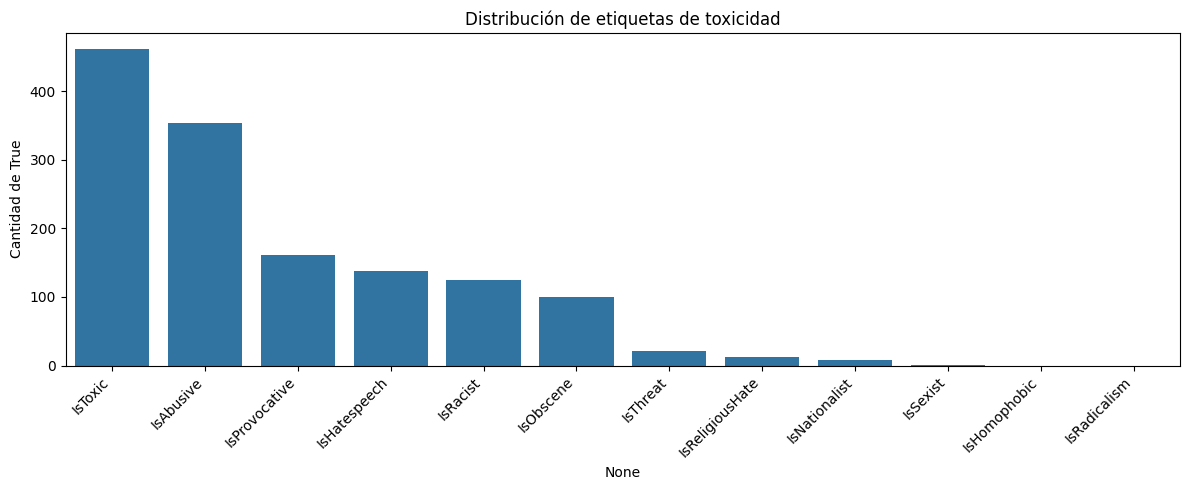

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns 

# Columnas de etiquetas
label_cols = ['IsToxic', 'IsAbusive', 'IsThreat', 'IsProvocative', 
              'IsObscene', 'IsHatespeech', 'IsRacist', 'IsNationalist', 
              'IsSexist', 'IsHomophobic', 'IsReligiousHate', 'IsRadicalism']

# Conteo de True por categoría
label_counts = df[label_cols].sum().sort_values(ascending=False)
print(label_counts)

# Visualización
plt.figure(figsize=(12, 5))
sns.barplot(x=label_counts.index, y=label_counts.values)
plt.xticks(rotation=45, ha='right')
plt.title('Distribución de etiquetas de toxicidad')
plt.ylabel('Cantidad de True')
plt.tight_layout()
plt.show()

## ⚖️ ¿Qué hacer con un dataset desbalanceado?

### 1️⃣ Técnicas de re-muestreo (las más comunes)

| Técnica | Qué hace | Cuándo usarla |
|---|---|---|
| **Oversampling** (SMOTE) | Genera ejemplos sintéticos de la clase minoritaria | Cuando tienes pocas filas en total |
| **Undersampling** | Reduce los ejemplos de la clase mayoritaria | Cuando tienes muchos datos |
| **Combinación** | Mezcla ambas | Caso general |

### 2️⃣ Ajustar los pesos del modelo

```python
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(class_weight='balanced')  # sklearn lo hace automático
```

### 3️⃣ Cambiar la métrica de evaluación

> ⚠️ Con datasets desbalanceados, el **Accuracy es mentiroso**. Usa mejor:

- **F1-Score** → equilibrio entre precisión y recall
- **ROC-AUC** → qué tan bien separa las clases
- **Precision / Recall** → según lo que te importe más

### 4️⃣ Eliminar columnas inútiles

Como `IsHomophobic` e `IsRadicalism` tienen **0 ejemplos**, no aportan nada:

```python
df.drop(columns=['IsHomophobic', 'IsRadicalism'], inplace=True)
```

## 🎯 Recomendación para el caso

Dado que es un proyecto de **prototipo con 1,000 filas**, la recomendación final es:

- ✅ Eliminar `IsHomophobic` e `IsRadicalism`
- ✅ Usar `class_weight='balanced'` en tu modelo
- ✅ Evaluar con **F1-Score** en lugar de Accuracy

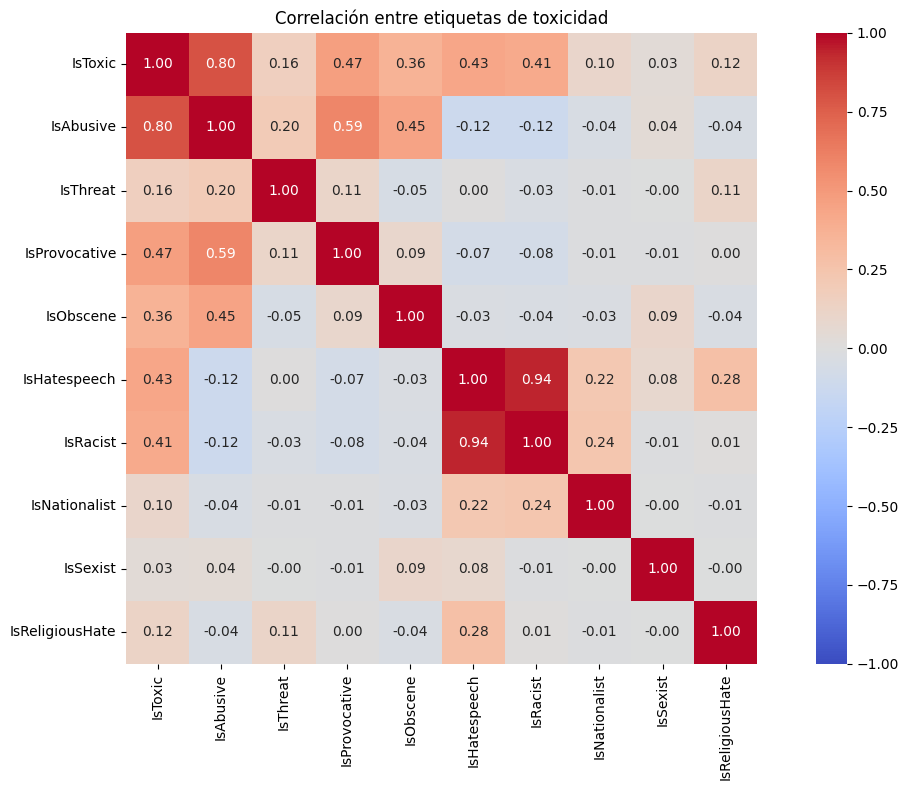

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

# Columnas de etiquetas (sin las que eliminamos)
label_cols = ['IsToxic', 'IsAbusive', 'IsThreat', 'IsProvocative', 
              'IsObscene', 'IsHatespeech', 'IsRacist', 'IsNationalist', 
              'IsSexist', 'IsReligiousHate']

# Calcular correlación
corr_matrix = df[label_cols].corr()

# Visualizar
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, 
            annot=True,        # muestra los números
            fmt='.2f',         # 2 decimales
            cmap='coolwarm',   # rojo=correlación alta, azul=baja
            vmin=-1, vmax=1,
            square=True)

plt.title('Correlación entre etiquetas de toxicidad')
plt.tight_layout()
plt.show()

## 🔍 Análisis del Mapa de Correlación

### Hallazgos principales

| Par de etiquetas | Correlación | Interpretación |
|---|---|---|
| `IsHatespeech` + `IsRacist` | **0.94** 🔴 | Casi siempre aparecen juntas |
| `IsToxic` + `IsAbusive` | **0.80** 🔴 | Fuerte relación general |
| `IsAbusive` + `IsProvocative` | **0.59** 🟠 | Correlación moderada-alta |
| `IsToxic` + `IsProvocative` | **0.47** 🟠 | Correlación moderada |
| `IsAbusive` + `IsHatespeech` | **-0.12** 🔵 | Ligera relación inversa |

---

### 🧹 Recomendaciones de limpieza

**1. Considerar fusionar `IsHatespeech` e `IsRacist`**
> Con una correlación de **0.94**, estas dos columnas dicen casi lo mismo.
> Fusionarlas reduce ruido y simplifica el modelo.

```python
df['IsHate_or_Racist'] = df[['IsHatespeech', 'IsRacist']].any(axis=1)
df.drop(columns=['IsHatespeech', 'IsRacist'], inplace=True)
```

**2. Mantener `IsThreat`, `IsSexist` e `IsReligiousHate`**
> Tienen correlaciones bajas con el resto (cercanas a 0),
> lo que significa que aportan información **independiente y valiosa**.

**3. Vigilar `IsToxic` como etiqueta general**
> Correlaciona con casi todo. Puede usarse como
> **variable objetivo principal** en un modelo binario simple.

## Longitud de comentarios 

       char_length   word_count
count  1000.000000  1000.000000
mean    185.554000    33.776000
std     270.780777    49.069498
min       3.000000     1.000000
25%      47.000000     9.000000
50%     101.000000    19.000000
75%     217.000000    39.000000
max    4421.000000   815.000000


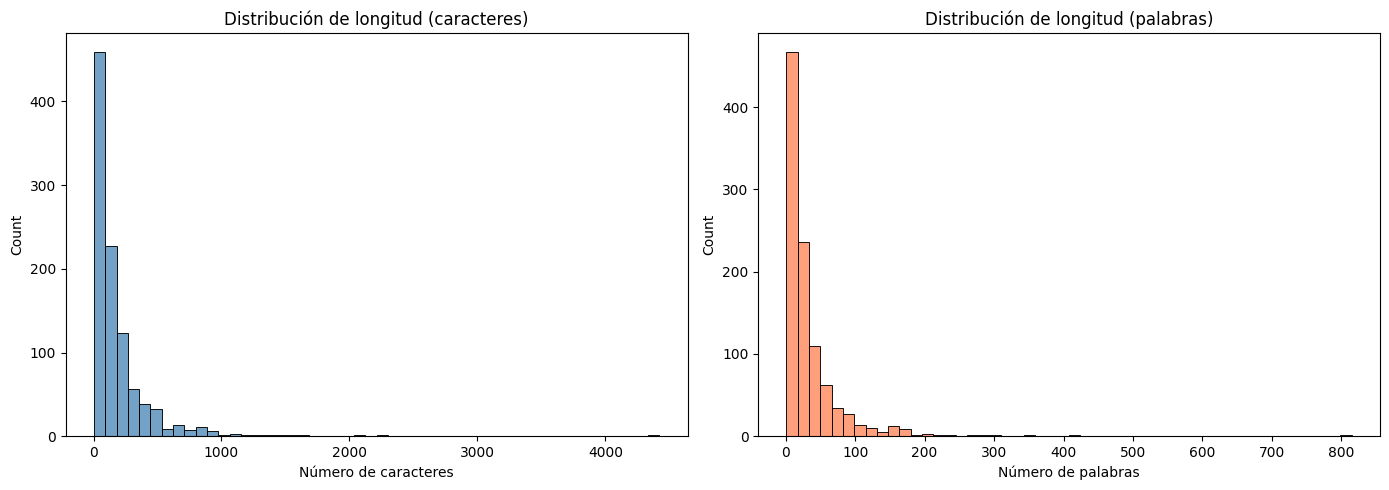

In [7]:
# Longitud en caracteres y palabras
df['char_length'] = df['Text'].apply(len)
df['word_count'] = df['Text'].apply(lambda x: len(x.split()))

# Estadísticas
print(df[['char_length', 'word_count']].describe())

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df['char_length'], bins=50, ax=axes[0], color='steelblue')
axes[0].set_title('Distribución de longitud (caracteres)')
axes[0].set_xlabel('Número de caracteres')

sns.histplot(df['word_count'], bins=50, ax=axes[1], color='coral')
axes[1].set_title('Distribución de longitud (palabras)')
axes[1].set_xlabel('Número de palabras')

plt.tight_layout()
plt.show()

## 📏 Interpretación de la Distribución de Longitud

### ¿Qué vemos?

- La **mayoría de comentarios** son cortos: menos de **200 caracteres** y menos de **40 palabras**
- Hay una **cola larga** hacia la derecha (pocos comentarios muy largos, hasta 4,500 caracteres)
- La distribución tiene forma de **cola sesgada a la derecha** — típico en texto de redes sociales

---

## 🧹 Recomendaciones de limpieza

### 1️⃣ Eliminar comentarios demasiado cortos

```python
# Comentarios con menos de 3 palabras probablemente no aportan info
df = df[df['word_count'] >= 3]
print(f"Filas restantes: {len(df)}")
```

### 2️⃣ Eliminar outliers extremos (comentarios gigantes)

```python
# Ver cuántos comentarios superan las 200 palabras
outliers = df[df['word_count'] > 200]
print(f"Comentarios muy largos: {len(outliers)}")

# Eliminarlos si son muy pocos
df = df[df['word_count'] <= 200]
```

### 3️⃣ Truncar en vez de eliminar (alternativa)

```python
# Si no quieres perder datos, trunca a 100 palabras
df['Text'] = df['Text'].apply(lambda x: ' '.join(x.split()[:100]))
```

---

## 💡 Lo que probablemente encontrarás

| Métrica | Valor estimado |
|---|---|
| Mediana de palabras | ~20-30 palabras |
| Comentarios con menos de 3 palabras | ~10-20 filas |
| Outliers extremos (+200 palabras) | ~5-15 filas |

## Palabras mas frecuentes 

In [9]:
from collections import Counter
import nltk.corpus
import nltk

nltk.download('stopwords')
stop_words = set(nltk.corpus.stopwords.words('english'))

# Separar comentarios tóxicos y no tóxicos
toxic_texts = df[df['IsToxic'] == True]['Text']
clean_texts = df[df['IsToxic'] == False]['Text']

def get_top_words(texts, n=20):
    words = ' '.join(texts).lower().split()
    words = [w for w in words if w not in stop_words and len(w) > 2]
    return Counter(words).most_common(n)

print("🔴 Top palabras TÓXICAS:")
print(get_top_words(toxic_texts))

print("\n🟢 Top palabras NO tóxicas:")
print(get_top_words(clean_texts))

🔴 Top palabras TÓXICAS:
[('black', 113), ('people', 109), ('get', 79), ('like', 75), ('white', 74), ('police', 64), ('would', 57), ('fuck', 47), ('brown', 44), ('one', 38), ('shot', 36), ('fucking', 33), ('officer', 31), ('guy', 30), ('cops', 30), ('stupid', 30), ('shit', 30), ('cop', 30), ('still', 28), ('blacks', 27)]

🟢 Top palabras NO tóxicas:
[('people', 113), ('black', 105), ('police', 92), ('like', 72), ('get', 64), ('would', 61), ('white', 54), ('brown', 46), ('officer', 44), ('video', 41), ('know', 38), ('shot', 37), ('one', 37), ('cop', 36), ('need', 29), ('cops', 29), ('thank', 28), ('much', 28), ('think', 28), ('going', 27)]


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Usuario\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


## 🔤 Análisis de Palabras Frecuentes

### ⚠️ El problema: palabras ambiguas

Palabras como `black`, `white`, `police`, `brown`, `shot` aparecen **casi igual** en tóxicos y no tóxicos.
Esto significa que el **contexto importa más que la palabra sola**.

| Palabra | En tóxicos | En no tóxicos |
|---|---|---|
| `black` | 113 | 105 |
| `people` | 109 | 113 |
| `police` | 64 | 92 |
| `brown` | 44 | 46 |

---

## 🧹 Recomendaciones de limpieza

### 1️⃣ Expandir las stopwords con palabras neutras

```python
custom_stopwords = stop_words.union({
    'people', 'get', 'like', 'would', 'one', 
    'still', 'going', 'know', 'think', 'much'
})
```

### 2️⃣ Limpiar el texto: puntuación, números y minúsculas

```python
import re

def clean_text(text):
    text = text.lower()                        # minúsculas
    text = re.sub(r'http\S+', '', text)        # eliminar URLs
    text = re.sub(r'[^a-zA-Z\s]', '', text)   # solo letras
    text = re.sub(r'\s+', ' ', text).strip()  # espacios extra
    return text

df['Text_clean'] = df['Text'].apply(clean_text)
```

### 3️⃣ Aplicar Lemmatization (mejor que stemming)

```python
import nltk
from nltk.stem import WordNetLemmatizer

nltk.download('wordnet')
lemmatizer = WordNetLemmatizer()

def lemmatize_text(text):
    words = text.split()
    return ' '.join([lemmatizer.lemmatize(w) for w in words])

df['Text_clean'] = df['Text_clean'].apply(lemmatize_text)
```

> Esto convierte `fucking` → `fuck`, `blacks` → `black`, `cops` → `cop`,
> reduciendo variantes de la misma palabra.

---

## 💡 Conclusión clave

> Las palabras `black`, `white`, `police` son **sensibles al contexto**, no inherentemente tóxicas.
> Por eso tu modelo necesitará algo más que frecuencia de palabras —
> considera usar **TF-IDF** o embeddings como **Word2Vec** en lugar de Bag of Words simple.

### Worldcloud Algo Visual 

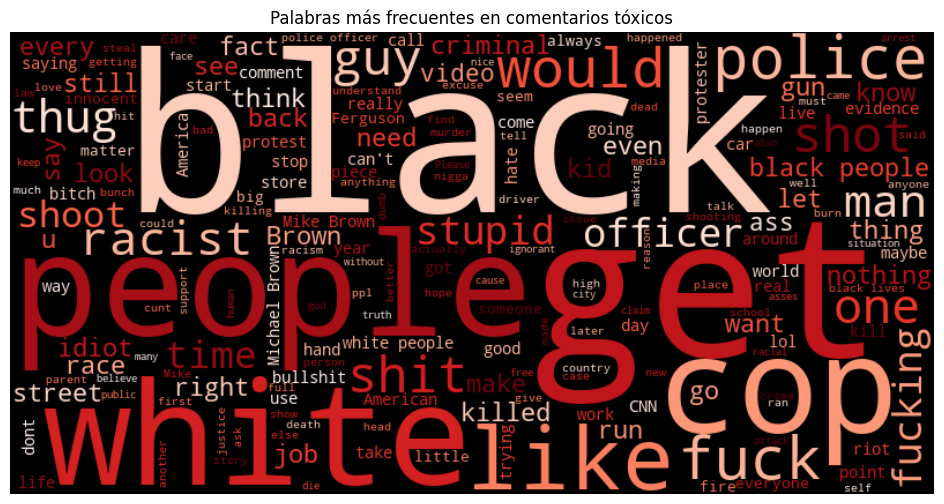

In [10]:
from wordcloud import WordCloud

toxic_words = ' '.join(toxic_texts)

wordcloud = WordCloud(
    width=800, height=400,
    background_color='black',
    colormap='Reds',
    stopwords=stop_words
).generate(toxic_words)

plt.figure(figsize=(14, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Palabras más frecuentes en comentarios tóxicos')
plt.show()

## Conteo del dataset en las clases desbanlanceadas

In [11]:
# Conteo de tóxicos vs no tóxicos
balance = df['IsToxic'].value_counts()
porcentaje = df['IsToxic'].value_counts(normalize=True) * 100

print("Conteo:")
print(balance)
print("\nPorcentaje:")
print(porcentaje.round(2))

Conteo:
IsToxic
False    538
True     462
Name: count, dtype: int64

Porcentaje:
IsToxic
False    53.8
True     46.2
Name: proportion, dtype: float64


C:\Users\Usuario\AppData\Local\Temp\ipykernel_7356\3288406951.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='IsToxic', data=df, palette=['steelblue', 'crimson'], ax=axes[0])
C:\Users\Usuario\AppData\Local\Temp\ipykernel_7356\3288406951.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['No Tóxico', 'Tóxico'])


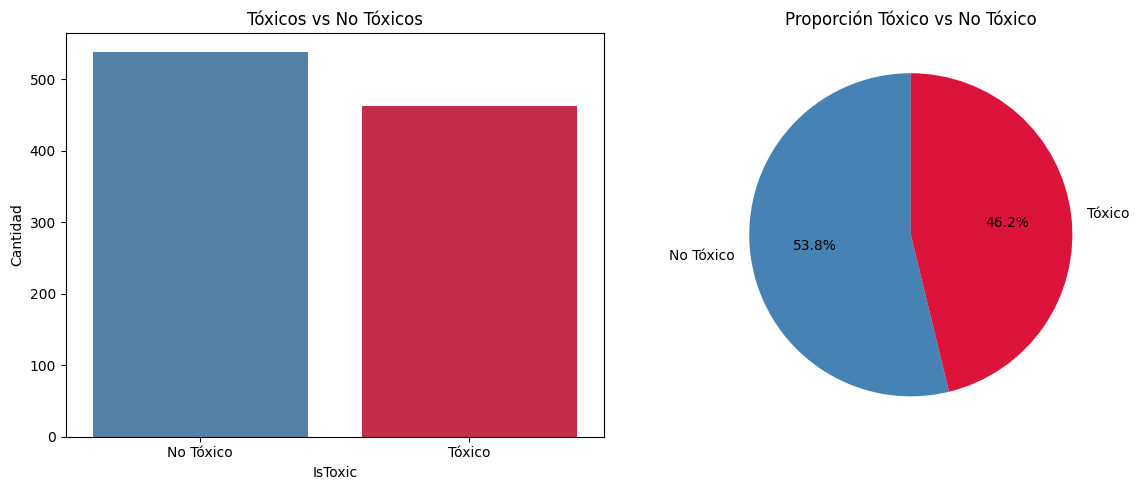

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Gráfico de barras
sns.countplot(x='IsToxic', data=df, palette=['steelblue', 'crimson'], ax=axes[0])
axes[0].set_title('Tóxicos vs No Tóxicos')
axes[0].set_xlabel('IsToxic')
axes[0].set_ylabel('Cantidad')
axes[0].set_xticklabels(['No Tóxico', 'Tóxico'])

# Gráfico de pastel
axes[1].pie(balance, 
            labels=['No Tóxico', 'Tóxico'],
            autopct='%1.1f%%',
            colors=['steelblue', 'crimson'],
            startangle=90)
axes[1].set_title('Proporción Tóxico vs No Tóxico')

plt.tight_layout()
plt.show()

## ⚖️ Balance del Dataset: Tóxicos vs No Tóxicos

### ¿Qué vemos?

| Clase | Cantidad | Porcentaje |
|---|---|---|
| 🔵 No Tóxico | ~538 | 53.8% |
| 🔴 Tóxico | ~462 | 46.2% |

### ¿Qué significa cada clase?

- **Tóxico** (`IsToxic = TRUE`) → El comentario contiene algún tipo de lenguaje dañino:
insultos, amenazas, racismo, sexismo, odio, etc.
- **No Tóxico** (`IsToxic = FALSE`) → El comentario es neutral, informativo
o simplemente una opinión sin contenido ofensivo.

---

##  El dataset está casi balanceado

> Una proporción **53/46 es excelente**. En datasets reales de toxicidad es común ver
> proporciones de **90/10 o peor**. Aquí casi no necesitas técnicas de balanceo.

### ¿Qué implica esto?

- ✅ **No se necesita SMOTE** ni undersampling agresivo
- ✅ Se Puede usar **Accuracy** como métrica (aunque F1 siempre es más robusto)
- ✅ El modelo no estará sesgado hacia una clase

---

## 🧹 Limpieza recomendada en este paso

Prácticamente ninguna, pero sí verificar:

```python
# Verificar que no haya nulos en IsToxic
print(df['IsToxic'].isnull().sum())

# Confirmar el conteo exacto
print(df['IsToxic'].value_counts())
```

---

## 💡 Conclusión clave

> Con un balance de **53.8% / 46.2%** podemos entrenar el modelo directamente
> sin técnicas especiales de balanceo. Hay que Enfócarse en la **limpieza del texto**
> que es donde está el verdadero reto.



##  Resumen Final de Limpieza antes del Modelado NLP

### 1️⃣ Columnas a eliminar

```python
# Sin ejemplos positivos — no aportan nada al modelo
df.drop(columns=['IsHomophobic', 'IsRadicalism'], inplace=True)

# Fusionar columnas con correlación 0.94 (casi idénticas)
df['IsHate_or_Racist'] = df[['IsHatespeech', 'IsRacist']].any(axis=1)
df.drop(columns=['IsHatespeech', 'IsRacist'], inplace=True)
```

### 2️⃣ Limpieza del texto

```python
import re

def clean_text(text):
    text = text.lower()                       # minúsculas
    text = re.sub(r'http\S+', '', text)       # eliminar URLs
    text = re.sub(r'[^a-zA-Z\s]', '', text)  # solo letras
    text = re.sub(r'\s+', ' ', text).strip() # espacios extra
    return text

df['Text_clean'] = df['Text'].apply(clean_text)
```

### 3️⃣ Eliminar comentarios muy cortos y outliers

```python
# Muy cortos — no aportan contexto
df = df[df['word_count'] >= 3]

# Outliers extremos
df = df[df['word_count'] <= 200]
```

### 4️⃣ Lemmatization

```python
from nltk.stem import WordNetLemmatizer
import nltk
nltk.download('wordnet')

lemmatizer = WordNetLemmatizer()

def lemmatize_text(text):
    words = text.split()
    return ' '.join([lemmatizer.lemmatize(w) for w in words])

df['Text_clean'] = df['Text_clean'].apply(lemmatize_text)
```

### 5️⃣ Stopwords personalizadas

```python
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

# Palabras ambiguas que aparecen igual en tóxico y no tóxico
custom_stopwords = stop_words.union({
    'people', 'get', 'like', 'would', 'one',
    'still', 'going', 'know', 'think', 'much'
})
```

---

## 🤖 Recomendaciones para el Modelado

### Representación del texto

| Opción | Cuándo usarla |
|---|---|
| **TF-IDF** | Modelo simple y rápido, buen punto de partida |
| **Word2Vec** | Captura contexto semántico, mejor para palabras ambiguas |
| **BERT** | Máxima precisión, pero requiere más recursos |

> ⚠️ Dado que palabras como `black`, `white`, `police` aparecen igual en tóxicos y no tóxicos,
> **TF-IDF solo no será suficiente**. Se recomienda **Word2Vec o BERT**.

### Métrica de evaluación

```python
from sklearn.metrics import classification_report

# Nunca uses solo Accuracy — usa F1
print(classification_report(y_test, y_pred))
```

### Modelo recomendado para empezar

```python
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(class_weight='balanced', max_iter=1000)
```

---

## ✅ Checklist final antes de entrenar

- [ ] Eliminar `IsHomophobic` e `IsRadicalism`
- [ ] Fusionar `IsHatespeech` + `IsRacist` → `IsHate_or_Racist`
- [ ] Limpiar texto (minúsculas, URLs, puntuación)
- [ ] Eliminar comentarios con menos de 3 palabras
- [ ] Eliminar outliers con más de 200 palabras
- [ ] Aplicar Lemmatization
- [ ] Usar stopwords personalizadas
- [ ] Usar **TF-IDF + Logistic Regression** como baseline
- [ ] Evaluar con **F1-Score**